In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

In [2]:
df = pd.read_csv('../01_cleaned_data/lola_sites_summary.csv')

print(f"Sites loaded: {len(df)}")
print(df[['Site', 'Meets_all_criteria', 'Unmet_criteria',
          'EZ_score', 'H2_max_ppm']].to_string(index=False))

Sites loaded: 9
               Site  Meets_all_criteria Unmet_criteria  EZ_score  H2_max_ppm
       Nobile Rim 2                True            NaN    0.9673      105.51
        Mons Mouton                True            NaN    0.6992      148.56
    Malapert Massif                True            NaN    0.9736      141.65
  de Gerlache Rim 2                True            NaN    0.8029      143.71
Mons Mouton Plateau                True            NaN    0.9320      107.84
       Slater Plain               False            DTE    0.8478      134.25
 Peak near Cabeus B               False          Slope    0.9472      149.18
       Nobile Rim 1                True            NaN    0.8538      151.88
            Haworth                True            NaN    0.8594      132.27


In [3]:
# criteria mapping to NASA's site selection requirements, ranked using
# CRITIC-derived weights (Diakoulaki et al., 1995) and TOPSIS
# (Peña-Asensio et al., Acta Astronautica, 2024) doi:10.1016/j.actaastro.2024.10.049

criteria_cols = ['Illumination_max', 'DTE_max', 'Pct_area_HLS_safe', 'H2_max_ppm']
directions    = ['+', '+', '+', '+']

def critic_weights(data):
    col_min  = data.min(axis=0)
    col_max  = data.max(axis=0)
    norm     = (data - col_min) / (col_max - col_min + 1e-12)
    std_j    = norm.std(axis=0, ddof=1)
    corr     = np.corrcoef(norm.T)
    conflict = (1 - corr).sum(axis=1)
    C        = std_j * conflict
    return C / C.sum()

def topsis(data, weights, directions):
    norm     = data / (np.sqrt((data**2).sum(axis=0)) + 1e-12)
    weighted = norm * weights
    dirs     = np.array(directions)
    best     = np.where(dirs == '+', weighted.max(axis=0), weighted.min(axis=0))
    worst    = np.where(dirs == '+', weighted.min(axis=0), weighted.max(axis=0))
    d_best   = np.sqrt(((weighted - best)  ** 2).sum(axis=1))
    d_worst  = np.sqrt(((weighted - worst) ** 2).sum(axis=1))
    return d_worst / (d_best + d_worst + 1e-12)

X        = df[criteria_cols].values.astype(float)
critic_w = critic_weights(X)

print("CRITIC weights:")
for col, w in zip(criteria_cols, critic_w):
    print(f"  {col:22s}  {w:.4f}  ({w*100:.1f}%)")

df['Weighted_score'] = topsis(X, critic_w, directions)

CRITIC weights:
  Illumination_max        0.1754  (17.5%)
  DTE_max                 0.2436  (24.4%)
  Pct_area_HLS_safe       0.3362  (33.6%)
  H2_max_ppm              0.2448  (24.5%)


In [4]:
scenarios = {
    'CRITIC weights':    critic_w,
    'Equal weights':     np.full(len(criteria_cols), 1/len(criteria_cols)),
    'Safety-first':      np.array([0.15, 0.15, 0.55, 0.15]),
    'Resource-priority': np.array([0.20, 0.15, 0.20, 0.45]),
}

sensitivity = {}
for name, w in scenarios.items():
    s    = topsis(X, w, directions)
    rank = pd.Series(s).rank(ascending=False).astype(int).values
    sensitivity[name] = {'scores': s, 'ranks': rank}

rank_df = pd.DataFrame({'Site': df['Site'].values})
for name, res in sensitivity.items():
    rank_df[name] = res['ranks']

rank_df['Rank_std'] = rank_df[list(scenarios.keys())].std(axis=1).round(2)
rank_df['Stable']   = rank_df['Rank_std'] <= 1.5

print("Sensitivity Analysis -- Rank Stability:")
print(rank_df.sort_values('CRITIC weights').to_string(index=False))
print(f"\nStable rankings (std <= 1.5): {rank_df['Stable'].sum()} / {len(rank_df)}")

Sensitivity Analysis -- Rank Stability:
               Site  CRITIC weights  Equal weights  Safety-first  Resource-priority  Rank_std  Stable
Mons Mouton Plateau               1              1             1                  3      1.00    True
            Haworth               2              2             2                  1      0.50    True
       Slater Plain               3              5             3                  4      0.96    True
       Nobile Rim 2               4              6             4                  7      1.50    True
       Nobile Rim 1               5              3             6                  2      1.83   False
  de Gerlache Rim 2               6              7             5                  6      0.82    True
    Malapert Massif               7              4             7                  5      1.50    True
        Mons Mouton               8              9             8                  8      0.50    True
 Peak near Cabeus B               9       

In [5]:
df_sorted = df.sort_values(
    by=['Meets_all_criteria', 'Weighted_score'],
    ascending=[False, False]
).reset_index(drop=True)
df_sorted['Rank'] = range(1, len(df_sorted) + 1)

print("Final Ranking -- Fully Compliant Sites First, then Partial Compliance")
print()
print(df_sorted[['Rank', 'Site', 'Meets_all_criteria', 'Unmet_criteria',
                  'Weighted_score', 'Pct_area_HLS_safe', 'Illumination_max',
                  'DTE_max', 'Has_PSR_access', 'PSR_dist_km', 'H2_max_ppm']]
      .to_string(index=False))

Final Ranking -- Fully Compliant Sites First, then Partial Compliance

 Rank                Site  Meets_all_criteria Unmet_criteria  Weighted_score  Pct_area_HLS_safe  Illumination_max  DTE_max  Has_PSR_access  PSR_dist_km  H2_max_ppm
    1 Mons Mouton Plateau                True            NaN        0.767803               82.0              52.0     99.5            True        0.708      107.84
    2             Haworth                True            NaN        0.744729               84.1              52.4     65.2            True        0.122      132.27
    3        Nobile Rim 2                True            NaN        0.557691               56.4              52.1     81.0            True        0.721      105.51
    4        Nobile Rim 1                True            NaN        0.500627               42.4              73.7     98.5            True        0.591      151.88
    5   de Gerlache Rim 2                True            NaN        0.473982               51.6              

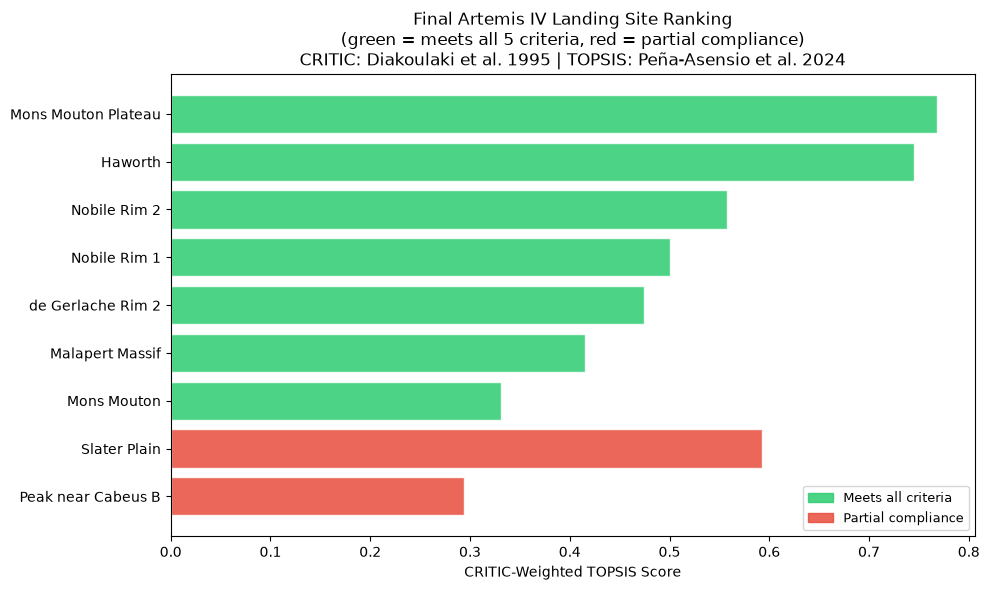

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = df_sorted.sort_values('Rank', ascending=False)
colors  = ['#2ecc71' if m else '#e74c3c' for m in plot_df['Meets_all_criteria']]

ax.barh(plot_df['Site'], plot_df['Weighted_score'],
        color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('CRITIC-Weighted TOPSIS Score')
ax.set_title('Final Artemis IV Landing Site Ranking\n'
             '(green = meets all 5 criteria, red = partial compliance)\n'
             'CRITIC: Diakoulaki et al. 1995 | TOPSIS: Peña-Asensio et al. 2024')

full = mpatches.Patch(color='#2ecc71', alpha=0.85, label='Meets all criteria')
part = mpatches.Patch(color='#e74c3c', alpha=0.85, label='Partial compliance')
ax.legend(handles=[full, part], fontsize=9)

plt.tight_layout()
plt.show()

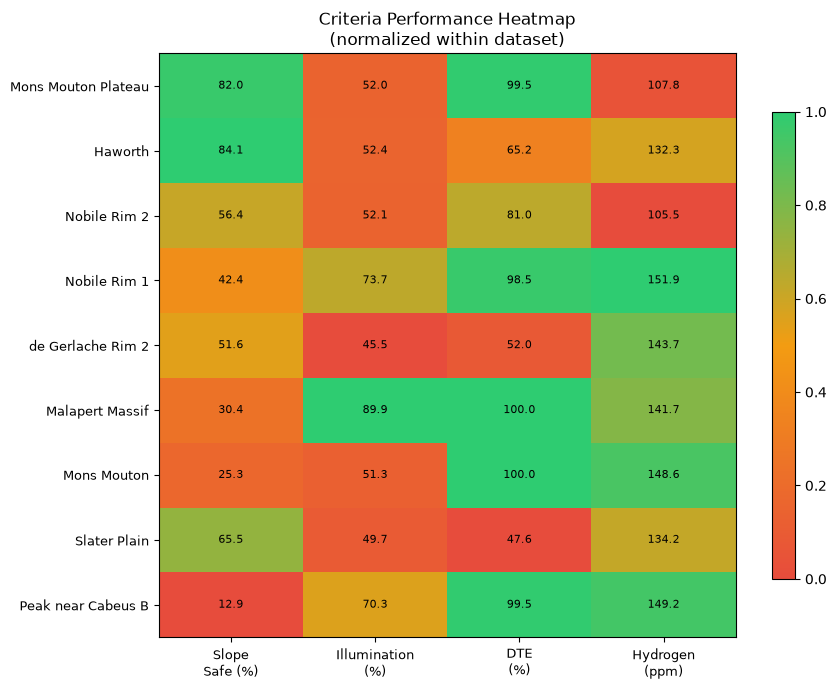

In [7]:
hm_cols   = ['Pct_area_HLS_safe', 'Illumination_max', 'DTE_max', 'H2_max_ppm']
hm_labels = ['Slope\nSafe (%)', 'Illumination\n(%)', 'DTE\n(%)', 'Hydrogen\n(ppm)']

hm_data   = df_sorted.set_index('Site')[hm_cols]
norm_data = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min() + 1e-12)

cmap = LinearSegmentedColormap.from_list('rg', ['#e74c3c', '#f39c12', '#2ecc71'])

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(norm_data.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(hm_cols)))
ax.set_xticklabels(hm_labels, fontsize=9)
ax.set_yticks(range(len(hm_data)))
ax.set_yticklabels(hm_data.index, fontsize=9)
ax.set_title('Criteria Performance Heatmap\n(normalized within dataset)')

for i in range(len(hm_data)):
    for j in range(len(hm_cols)):
        val = hm_data.values[i, j]
        ax.text(j, i, f'{val:.1f}' if val > 10 else f'{val:.2f}',
                ha='center', va='center', fontsize=8, color='black')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [8]:
out_cols = ['Rank', 'Site', 'Lat', 'Lon', 'EZ_X_stereo', 'EZ_Y_stereo',
            'Meets_all_criteria', 'Unmet_criteria',
            'Weighted_score', 'Pct_area_HLS_safe', 'Illumination_max',
            'Illumination_mean', 'DTE_max', 'DTE_mean',
            'Has_PSR_access', 'PSR_dist_km', 'PSR_traverse_ok',
            'H2_max_ppm', 'H2_mean_ppm',
            'Elevation_mean_m', 'Elevation_std_m', 'Area_km2']

final_out = df_sorted[out_cols].copy()
final_out['Weighted_score'] = final_out['Weighted_score'].round(4)
final_out.to_csv('../01_cleaned_data/artemis_site_ranking.csv', index=False)

print("Saved: artemis_site_ranking.csv\n")
print(f"Sites meeting ALL criteria: {df_sorted['Meets_all_criteria'].sum()} / {len(df_sorted)}")
print()
print("Top recommended site(s):")
for _, row in final_out[final_out['Meets_all_criteria']].head(3).iterrows():
    print(f"\n  #{row['Rank']} {row['Site']}")
    print(f"     Score:          {row['Weighted_score']:.4f}")
    print(f"     Slope safe:     {row['Pct_area_HLS_safe']:.1f}%")
    print(f"     Illumination:   {row['Illumination_max']:.1f}%")
    print(f"     DTE:            {row['DTE_max']:.1f}%")
    print(f"     PSR distance:   {row['PSR_dist_km']:.2f} km")
    print(f"     Hydrogen (max): {row['H2_max_ppm']:.1f} ppm")

Saved: artemis_site_ranking.csv

Sites meeting ALL criteria: 7 / 9

Top recommended site(s):

  #1 Mons Mouton Plateau
     Score:          0.7678
     Slope safe:     82.0%
     Illumination:   52.0%
     DTE:            99.5%
     PSR distance:   0.71 km
     Hydrogen (max): 107.8 ppm

  #2 Haworth
     Score:          0.7447
     Slope safe:     84.1%
     Illumination:   52.4%
     DTE:            65.2%
     PSR distance:   0.12 km
     Hydrogen (max): 132.3 ppm

  #3 Nobile Rim 2
     Score:          0.5577
     Slope safe:     56.4%
     Illumination:   52.1%
     DTE:            81.0%
     PSR distance:   0.72 km
     Hydrogen (max): 105.5 ppm
